# 🚍 Saskatoon Transit Route Experience KPI

## Which routes look good on paper but may feel worse to riders?

### Objective
This notebook uses Saskatoon Transit GTFS data to create route-level operational metrics, then layers on an illustrative rider-experience score to show how route rankings can change when rider experience is included.

The goal is not to claim definitive route-level rider satisfaction. The goal is to demonstrate a practical analytics approach: combine operational transit data with rider feedback signals to help agencies prioritize where service may need attention.

---

## 1. Analysis framing

Transit agencies often track operational metrics such as trip volume, service coverage, on-time performance, and route productivity. These metrics are necessary, but they may not fully capture what riders experience day to day: crowding, discomfort, delay frustration, cleanliness, accessibility, or communication quality.

### Core question

**Which Saskatoon Transit routes look strong based on service volume, but drop when rider experience is considered?**

### Method

1. Use GTFS files to calculate route-level service metrics.
2. Build a simple **Paper KPI** based on operational service volume.
3. Add an illustrative **Experience KPI** using rider-experience penalty inputs such as crowding, delay pressure, and sentiment.
4. Compare the rankings and identify routes with the largest gaps.

In [2]:
#Import libraries 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 2. Load GTFS data

The uploaded files include standard GTFS-style tables:

- `Transit_Routes.csv`: route names and route IDs
- `Transit_Trips.csv`: trips by route and service calendar
- `Transit_Calendar.csv`: service days
- `Transit_Stop_Times.csv`: stop times by trip
- `Transit_Shapes.csv`: geographic route shape points

This analysis mainly uses `routes`, `trips`, `calendar`, and `stop_times`.

In [4]:
DATA_DIR = Path(".")
if not (DATA_DIR / "Transit_Routes.csv").exists():
    DATA_DIR = Path("/mnt/data")

# Load your files
routes = pd.read_csv('Data/Transit_Routes.csv')
calendar = pd.read_csv('Data/Transit_Calendar.csv') 
trips  = pd.read_csv('Data/Transit_Trips.csv')
stop_times = pd.read_csv('Data/Transit_Stop_Times.csv')

#shapes = pd.read_csv('Data/Transit_Shapes.csv')
#stops = pd.read_csv('Data/Transit_Stops.csv')

In [5]:
print("routes:", routes.shape)
print("calendar:", calendar.shape)
print("trips:", trips.shape)
print("stop_times:", stop_times.shape)

routes: (54, 10)
calendar: (6, 11)
trips: (6313, 11)
stop_times: (128220, 11)


## 3. Create route-level operational metrics

For the **Paper KPI**, we use service volume as the base operational signal. In this notebook, service volume is represented by total scheduled trips per route.

This is a reasonable proxy for how much service the agency provides, but it is not a complete measure of service quality.

In [6]:
route_metrics = (
    trips.groupby(["route_id", "service_id"])
    .size()
    .reset_index(name="trip_count")
    .merge(routes[["route_id", "route_short_name", "route_long_name"]], on="route_id", how="left")
    .merge(calendar, on="service_id", how="left")
    .groupby(["route_id", "route_short_name", "route_long_name"], as_index=False)
    .agg(
        total_trips=("trip_count", "sum"),
        weekday_service=("monday", "max"), #Proxy for weekday service
        saturday_service=("saturday", "max"),
        sunday_service=("sunday", "max"),
    )
)

route_metrics["weekend_service"] = route_metrics[["saturday_service", "sunday_service"]].max(axis=1)
route_metrics["route_short_name"] = route_metrics["route_short_name"].astype(str)

route_metrics.sort_values("total_trips", ascending=False).head(10)

,route_id,route_short_name,route_long_name,total_trips,weekday_service,saturday_service,sunday_service,weekend_service
15,14646,17,Stonebridge / Lawson,385,1,1,1,1
7,14638,8,8th Street / City Centre,373,1,1,1,1
1,14632,2,Meadowgreen / City Centre,241,1,1,1,1
3,14634,4,City Centre,239,1,1,1,1
4,14635,5,City Centre / Confederation,236,1,1,1,1
0,14631,1,City Centre / Exhibition,220,1,1,1,1
9,14640,10,Centre Mall / University,201,1,1,1,1
13,14644,15,City Centre / Civic Op Centre,200,1,1,1,1
23,14654,30,Lawson Heights / City Centre,186,1,1,1,1
32,14664,35,Silverwood / City Centre,183,1,1,1,1


## 4. Add peak-period service context

A route can have many trips overall, but still feel stretched if demand is concentrated during commute periods. To add basic time-of-day context, we estimate the number of trip starts during the morning and afternoon peak periods.

Peak windows used here:

- Morning peak: 7:00–9:59
- Afternoon peak: 15:00–18:59

In [7]:
def gtfs_time_to_hour(value):
    """Convert GTFS HH:MM:SS strings to hour. GTFS can exceed 24:00:00."""
    if pd.isna(value):
        return np.nan
    parts = str(value).split(":")
    if len(parts) != 3:
        return np.nan
    return int(parts[0])

# First recorded stop time per trip is used as a trip-start proxy
trip_starts = (
    stop_times.sort_values(["trip_id", "stop_sequence"])
    .groupby("trip_id", as_index=False)
    .first()[["trip_id", "departure_time"]]
)
trip_starts["start_hour"] = trip_starts["departure_time"].apply(gtfs_time_to_hour)

trip_route = trips[["trip_id", "route_id"]].merge(trip_starts, on="trip_id", how="left")
trip_route["is_peak"] = trip_route["start_hour"].between(7, 9) | trip_route["start_hour"].between(15, 18)

peak_metrics = (
    trip_route.groupby("route_id", as_index=False)
    .agg(
        peak_trips=("is_peak", "sum"),
        trips_with_start_time=("start_hour", "count")
    )
)

route_metrics = route_metrics.merge(peak_metrics, on="route_id", how="left")
route_metrics[["peak_trips", "trips_with_start_time"]] = route_metrics[["peak_trips", "trips_with_start_time"]].fillna(0)

route_metrics.sort_values("peak_trips", ascending=False).head(10)

,route_id,route_short_name,route_long_name,total_trips,weekday_service,saturday_service,sunday_service,weekend_service,peak_trips,trips_with_start_time
15,14646,17,Stonebridge / Lawson,385,1,1,1,1,188,360
7,14638,8,8th Street / City Centre,373,1,1,1,1,160,361
3,14634,4,City Centre,239,1,1,1,1,103,228
13,14644,15,City Centre / Civic Op Centre,200,1,1,1,1,103,200
4,14635,5,City Centre / Confederation,236,1,1,1,1,101,216
1,14632,2,Meadowgreen / City Centre,241,1,1,1,1,100,231
0,14631,1,City Centre / Exhibition,220,1,1,1,1,92,209
9,14640,10,Centre Mall / University,201,1,1,1,1,83,192
52,14684,86,Rosewood / Centre Mall,176,1,1,1,1,76,168
51,14683,84,Briarwood / Centre Mall,174,1,1,1,1,73,170


## 5. Build the Paper KPI

The **Paper KPI** represents how strong the route looks from an operational service perspective.

For this version, it combines:

- 70% total scheduled trips
- 20% peak-period trips
- 10% weekend service availability

Higher values are better.

In [9]:
def minmax(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(1, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

route_metrics["trip_volume_score"] = minmax(route_metrics["total_trips"])
route_metrics["peak_service_score"] = minmax(route_metrics["peak_trips"])
route_metrics["weekend_score"] = route_metrics["weekend_service"].fillna(0).astype(float)

route_metrics["paper_kpi"] = (
    0.70 * route_metrics["trip_volume_score"] +
    0.20 * route_metrics["peak_service_score"] +
    0.10 * route_metrics["weekend_score"]
)

route_metrics["paper_rank"] = route_metrics["paper_kpi"].rank(ascending=False, method="dense").astype(int)

route_metrics.sort_values("paper_rank").head(10)[[
    "route_short_name", "route_long_name", "total_trips", "peak_trips", "paper_kpi", "paper_rank"
]]

,route_short_name,route_long_name,total_trips,peak_trips,paper_kpi,paper_rank
15,17,Stonebridge / Lawson,385,188,1.000000,1
7,8,8th Street / City Centre,373,160,0.948338,2
1,2,Meadowgreen / City Centre,241,100,0.643883,3
3,4,City Centre,239,103,0.643429,4
4,5,City Centre / Confederation,236,101,0.635832,5
0,1,City Centre / Exhibition,220,92,0.597091,6
13,15,City Centre / Civic Op Centre,200,103,0.572335,7
9,10,Centre Mall / University,201,83,0.552881,8
23,30,Lawson Heights / City Centre,186,72,0.513835,9
32,35,Silverwood / City Centre,183,72,0.508367,10


## 6. Add illustrative rider-experience inputs

Structured route-level complaint data was not available in the uploaded GTFS files. To demonstrate the method, this notebook uses an illustrative rider-experience input table.

The values below should be interpreted as placeholders that could be replaced with real rider survey data, app feedback, complaint logs, or social listening data.

Variables:

- `crowding`: 0 to 1, where 1 means severe perceived crowding
- `delay_pressure`: 0 to 1, where 1 means severe perceived delay frustration
- `sentiment`: 1 to 5, where 1 is very negative and 5 is very positive
- `feedback_sample`: number of feedback signals assumed for the route

In [11]:
experience_inputs = pd.DataFrame([
    {"route_short_name": "17", "crowding": 0.90, "delay_pressure": 0.75, "sentiment": 2.1, "feedback_sample": 42},
    {"route_short_name": "8",  "crowding": 0.85, "delay_pressure": 0.70, "sentiment": 2.4, "feedback_sample": 38},
    {"route_short_name": "2",  "crowding": 0.55, "delay_pressure": 0.45, "sentiment": 3.0, "feedback_sample": 24},
    {"route_short_name": "4",  "crowding": 0.40, "delay_pressure": 0.35, "sentiment": 3.5, "feedback_sample": 18},
    {"route_short_name": "5",  "crowding": 0.60, "delay_pressure": 0.55, "sentiment": 2.8, "feedback_sample": 22},
    {"route_short_name": "1",  "crowding": 0.50, "delay_pressure": 0.40, "sentiment": 3.2, "feedback_sample": 16},
    {"route_short_name": "10", "crowding": 0.70, "delay_pressure": 0.65, "sentiment": 2.7, "feedback_sample": 20},
    {"route_short_name": "15", "crowding": 0.30, "delay_pressure": 0.30, "sentiment": 3.8, "feedback_sample": 12},
    {"route_short_name": "30", "crowding": 0.45, "delay_pressure": 0.35, "sentiment": 3.4, "feedback_sample": 13},
    {"route_short_name": "35", "crowding": 0.50, "delay_pressure": 0.40, "sentiment": 3.1, "feedback_sample": 14},
])

experience_inputs

,route_short_name,crowding,delay_pressure,sentiment,feedback_sample
0,17,0.90,0.75,2.1,42
1,8,0.85,0.70,2.4,38
2,2,0.55,0.45,3.0,24
3,4,0.40,0.35,3.5,18
4,5,0.60,0.55,2.8,22
5,1,0.50,0.40,3.2,16
6,10,0.70,0.65,2.7,20
7,15,0.30,0.30,3.8,12
8,30,0.45,0.35,3.4,13
9,35,0.50,0.40,3.1,14


## 7. Build the Experience KPI

The **Experience KPI** starts from the Paper KPI and applies an experience penalty based on crowding, delay pressure, and negative sentiment.

Penalty logic:

- Higher crowding increases the penalty
- Higher delay pressure increases the penalty
- Lower sentiment increases the penalty

Routes without illustrative feedback inputs keep their Paper KPI score and are flagged as having no feedback sample.

In [12]:
route_metrics = route_metrics.merge(experience_inputs, on="route_short_name", how="left")
route_metrics["has_feedback_sample"] = route_metrics["feedback_sample"].notna()

# For missing feedback rows, keep neutral values so the KPI remains unchanged after applying zero penalty.
route_metrics["crowding"] = route_metrics["crowding"].fillna(0)
route_metrics["delay_pressure"] = route_metrics["delay_pressure"].fillna(0)
route_metrics["sentiment"] = route_metrics["sentiment"].fillna(5)
route_metrics["feedback_sample"] = route_metrics["feedback_sample"].fillna(0).astype(int)

route_metrics["negative_sentiment"] = 1 - (route_metrics["sentiment"] / 5)

route_metrics["experience_penalty"] = (
    0.40 * route_metrics["crowding"] +
    0.35 * route_metrics["delay_pressure"] +
    0.25 * route_metrics["negative_sentiment"]
)

# Cap penalty so the metric remains interpretable and non-negative.
route_metrics["experience_penalty"] = route_metrics["experience_penalty"].clip(0, 0.85)
route_metrics["experience_kpi"] = route_metrics["paper_kpi"] * (1 - route_metrics["experience_penalty"])

route_metrics["experience_rank"] = route_metrics["experience_kpi"].rank(ascending=False, method="dense").astype(int)
route_metrics["rank_gap"] = route_metrics["experience_rank"] - route_metrics["paper_rank"]

route_metrics.sort_values("paper_rank").head(12)[[
    "route_short_name", "route_long_name", "paper_kpi", "experience_kpi", "paper_rank", "experience_rank", "rank_gap", "has_feedback_sample"
]]

,route_short_name,route_long_name,paper_kpi,experience_kpi,paper_rank,experience_rank,rank_gap,has_feedback_sample
15,17,Stonebridge / Lawson,1.000000,0.232500,1,33,32,True
7,8,8th Street / City Centre,0.948338,0.270276,2,32,30,True
1,2,Meadowgreen / City Centre,0.643883,0.336429,3,28,25,True
3,4,City Centre,0.643429,0.413403,4,21,17,True
4,5,City Centre / Confederation,0.635832,0.290893,5,30,25,True
0,1,City Centre / Exhibition,0.597091,0.340342,6,27,21,True
13,15,City Centre / Civic Op Centre,0.572335,0.409219,7,23,16,True
9,10,Centre Mall / University,0.552881,0.208713,8,35,27,True
23,30,Lawson Heights / City Centre,0.513835,0.317293,9,29,20,True
32,35,Silverwood / City Centre,0.508367,0.287227,10,31,21,True


## 8. Identify routes with the biggest ranking gaps

A positive `rank_gap` means the route performs worse under the Experience KPI than under the Paper KPI.

For example:

- `paper_rank = 1`, `experience_rank = 6` means the route looks strongest operationally, but drops to 6th when rider experience is considered.
- This is a potential **priority route** because the agency may be investing significant service but riders may still feel dissatisfied.

In [13]:
worst_gaps = (
    route_metrics[route_metrics["has_feedback_sample"]]
    .sort_values("rank_gap", ascending=False)
    .head(5)
    [["route_short_name", "route_long_name", "paper_rank", "experience_rank", "rank_gap", "crowding", "delay_pressure", "sentiment"]]
)

best_gaps = (
    route_metrics[route_metrics["has_feedback_sample"]]
    .sort_values("rank_gap", ascending=True)
    .head(5)
    [["route_short_name", "route_long_name", "paper_rank", "experience_rank", "rank_gap", "crowding", "delay_pressure", "sentiment"]]
)

print("Routes that drop the most when experience is included:")
display(worst_gaps)

print("\nRoutes that hold up or improve under the experience lens:")
display(best_gaps)

Routes that drop the most when experience is included:


,route_short_name,route_long_name,paper_rank,experience_rank,rank_gap,crowding,delay_pressure,sentiment
15,17,Stonebridge / Lawson,1,33,32,0.90,0.75,2.1
7,8,8th Street / City Centre,2,32,30,0.85,0.70,2.4
9,10,Centre Mall / University,8,35,27,0.70,0.65,2.7
1,2,Meadowgreen / City Centre,3,28,25,0.55,0.45,3.0
4,5,City Centre / Confederation,5,30,25,0.60,0.55,2.8



Routes that hold up or improve under the experience lens:


,route_short_name,route_long_name,paper_rank,experience_rank,rank_gap,crowding,delay_pressure,sentiment
13,15,City Centre / Civic Op Centre,7,23,16,0.30,0.30,3.8
3,4,City Centre,4,21,17,0.40,0.35,3.5
23,30,Lawson Heights / City Centre,9,29,20,0.45,0.35,3.4
0,1,City Centre / Exhibition,6,27,21,0.50,0.40,3.2
32,35,Silverwood / City Centre,10,31,21,0.50,0.40,3.1


## 9. Visualization: Paper KPI vs Experience KPI

This chart shows the core argument visually.

- Routes near the diagonal line have similar operational and experience-adjusted performance.
- Routes below the line are penalized by rider-experience inputs.
- The annotated routes are the largest ranking-gap routes among the feedback sample.

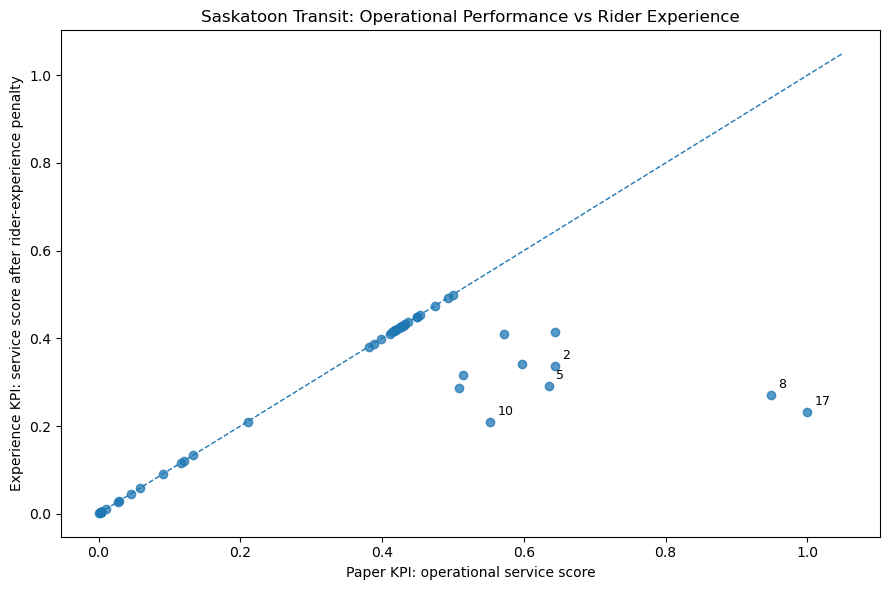

In [14]:
plot_df = route_metrics.copy()

plt.figure(figsize=(9, 6))
plt.scatter(plot_df["paper_kpi"], plot_df["experience_kpi"], alpha=0.75)

# Diagonal reference line
lims = [0, max(plot_df["paper_kpi"].max(), plot_df["experience_kpi"].max()) * 1.05]
plt.plot(lims, lims, linestyle="--", linewidth=1)

# Annotate top ranking-gap routes
for _, row in worst_gaps.iterrows():
    match = plot_df[plot_df["route_short_name"] == row["route_short_name"]].iloc[0]
    plt.annotate(
        str(match["route_short_name"]),
        (match["paper_kpi"], match["experience_kpi"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

plt.xlabel("Paper KPI: operational service score")
plt.ylabel("Experience KPI: service score after rider-experience penalty")
plt.title("Saskatoon Transit: Operational Performance vs Rider Experience")
plt.tight_layout()
plt.show()

## 10. Visualization: largest ranking gaps

This chart focuses only on routes with illustrative feedback inputs and shows how far each route moves when rider experience is included.

Positive values indicate routes that become lower priority in the experience ranking compared with the paper ranking.

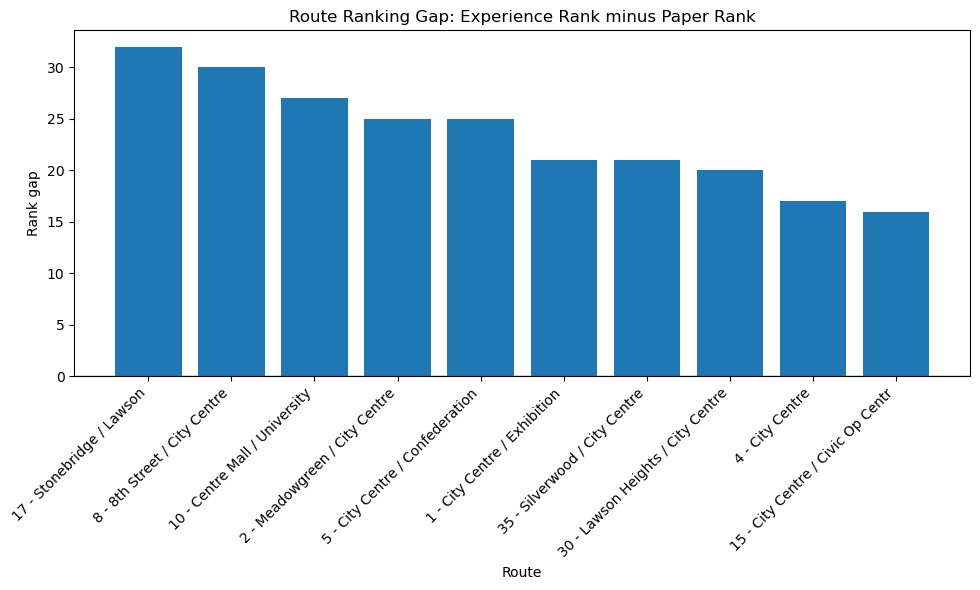

In [15]:
gap_plot = (
    route_metrics[route_metrics["has_feedback_sample"]]
    .sort_values("rank_gap", ascending=False)
    .copy()
)

gap_plot["route_label"] = gap_plot["route_short_name"] + " - " + gap_plot["route_long_name"].str.slice(0, 28)

plt.figure(figsize=(10, 6))
plt.bar(gap_plot["route_label"], gap_plot["rank_gap"])
plt.axhline(0, linewidth=1)
plt.title("Route Ranking Gap: Experience Rank minus Paper Rank")
plt.xlabel("Route")
plt.ylabel("Rank gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Final insights

### 1. Operational strength does not automatically mean rider satisfaction

Some high-service routes rank strongly on the Paper KPI but drop once rider-experience penalties are applied. This suggests that high service volume alone may not resolve rider pain if crowding, delay frustration, or negative sentiment remain high.

### 2. The highest-service routes can also be the highest-pain routes

Routes with more scheduled service often represent important corridors. If these routes also show high experience penalties, they should be treated as priority corridors because improvements may affect a large number of riders.

### 3. Ranking gaps create a practical prioritization tool

The `rank_gap` metric helps identify routes where operational investment and rider experience may be misaligned. A large positive gap means a route looks good on paper but worse from the rider perspective.

### 4. A hybrid KPI can support better transit planning

Traditional metrics are necessary, but a hybrid view that combines operational data with rider feedback can help agencies identify routes that need attention beyond simply adding trips.

## 12. Recommendations

### Recommendation 1: Use an Experience-Weighted KPI alongside existing metrics

Transit agencies should not replace operational KPIs, but they can supplement them with rider-centric signals such as crowding, delay perception, cleanliness, accessibility, and sentiment.

### Recommendation 2: Prioritize high-volume, high-pain routes

Routes with high Paper KPI scores and large positive rank gaps should be investigated first. These are corridors where service supply may be high but rider experience may still be poor.

### Recommendation 3: Track issue clusters, not just isolated complaints

Crowding and delays often reinforce each other. A route with moderate delay issues and moderate crowding issues may create a worse rider experience than either metric suggests alone.

### Recommendation 4: Build a feedback loop

A lightweight rider feedback system could continuously update route-level experience signals and help planners evaluate whether interventions are improving rider perception.

## 13. Limitations

This notebook is a demonstration of an analytical framework, not a definitive assessment of Saskatoon Transit rider satisfaction.

Key limitations:

- GTFS data shows scheduled service, not actual delays or vehicle loads.
- Route-level rider complaints were not available in the uploaded data.
- Experience inputs are illustrative placeholders and should be replaced with real feedback data.
- The KPI weights are judgment-based and should be validated with stakeholders.
- The analysis does not include stop-level accessibility, land-use context, or demographic equity measures.

Despite these limitations, the framework is useful because it shows how operational data and rider experience data can be combined into a decision-support tool.

## 14. Export results

The final route ranking table is saved as `output/saskatoon_route_rankings.csv`.

In [17]:
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

final_columns = [
    "route_id", "route_short_name", "route_long_name",
    "total_trips", "peak_trips", "paper_kpi", "experience_kpi",
    "paper_rank", "experience_rank", "rank_gap",
    "has_feedback_sample", "crowding", "delay_pressure", "sentiment", "feedback_sample"
]

final_route_rankings = route_metrics[final_columns].sort_values(["has_feedback_sample", "rank_gap"], ascending=[False, False])
final_route_rankings.to_csv(OUTPUT_DIR / "saskatoon_route_rankings.csv", index=False)

final_route_rankings.head(15)

,route_id,route_short_name,route_long_name,total_trips,peak_trips,paper_kpi,experience_kpi,paper_rank,experience_rank,rank_gap,has_feedback_sample,crowding,delay_pressure,sentiment,feedback_sample
15,14646,17,Stonebridge / Lawson,385,188,1.000000,0.232500,1,33,32,True,0.90,0.75,2.1,42
7,14638,8,8th Street / City Centre,373,160,0.948338,0.270276,2,32,30,True,0.85,0.70,2.4,38
9,14640,10,Centre Mall / University,201,83,0.552881,0.208713,8,35,27,True,0.70,0.65,2.7,20
1,14632,2,Meadowgreen / City Centre,241,100,0.643883,0.336429,3,28,25,True,0.55,0.45,3.0,24
4,14635,5,City Centre / Confederation,236,101,0.635832,0.290893,5,30,25,True,0.60,0.55,2.8,22
0,14631,1,City Centre / Exhibition,220,92,0.597091,0.340342,6,27,21,True,0.50,0.40,3.2,16
32,14664,35,Silverwood / City Centre,183,72,0.508367,0.287227,10,31,21,True,0.50,0.40,3.1,14
23,14654,30,Lawson Heights / City Centre,186,72,0.513835,0.317293,9,29,20,True,0.45,0.35,3.4,13
3,14634,4,City Centre,239,103,0.643429,0.413403,4,21,17,True,0.40,0.35,3.5,18
13,14644,15,City Centre / Civic Op Centre,200,103,0.572335,0.409219,7,23,16,True,0.30,0.30,3.8,12


## 15. One-line conclusion

**This analysis shows that routes which appear strong based on scheduled service may still underperform when evaluated through the lens of rider experience, highlighting the need for experience-weighted performance measurement in transit planning.**